# Diabetic Data Preprocessing and Exploratory Data Analysis (EDA)
This notebook performs data preprocessing and exploratory data analysis on `diabetic_data_cleaned.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("diabetic_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Dataset Information

In [2]:
df.info()
print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head())
print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Remove Duplicates

In [3]:
df = df.drop_duplicates()
print("New Shape:", df.shape)

New Shape: (101766, 50)


## Statistical Summary

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


## Target Variable Distribution

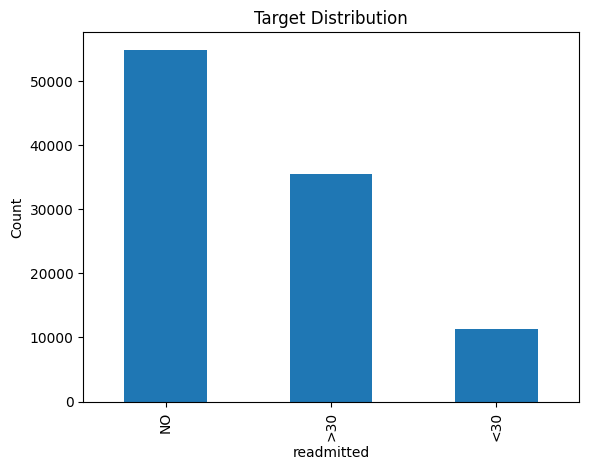

In [5]:
target = "readmitted_binary" if "readmitted_binary" in df.columns else "readmitted"
df[target].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel(target)
plt.ylabel("Count")
plt.show()

## Histograms

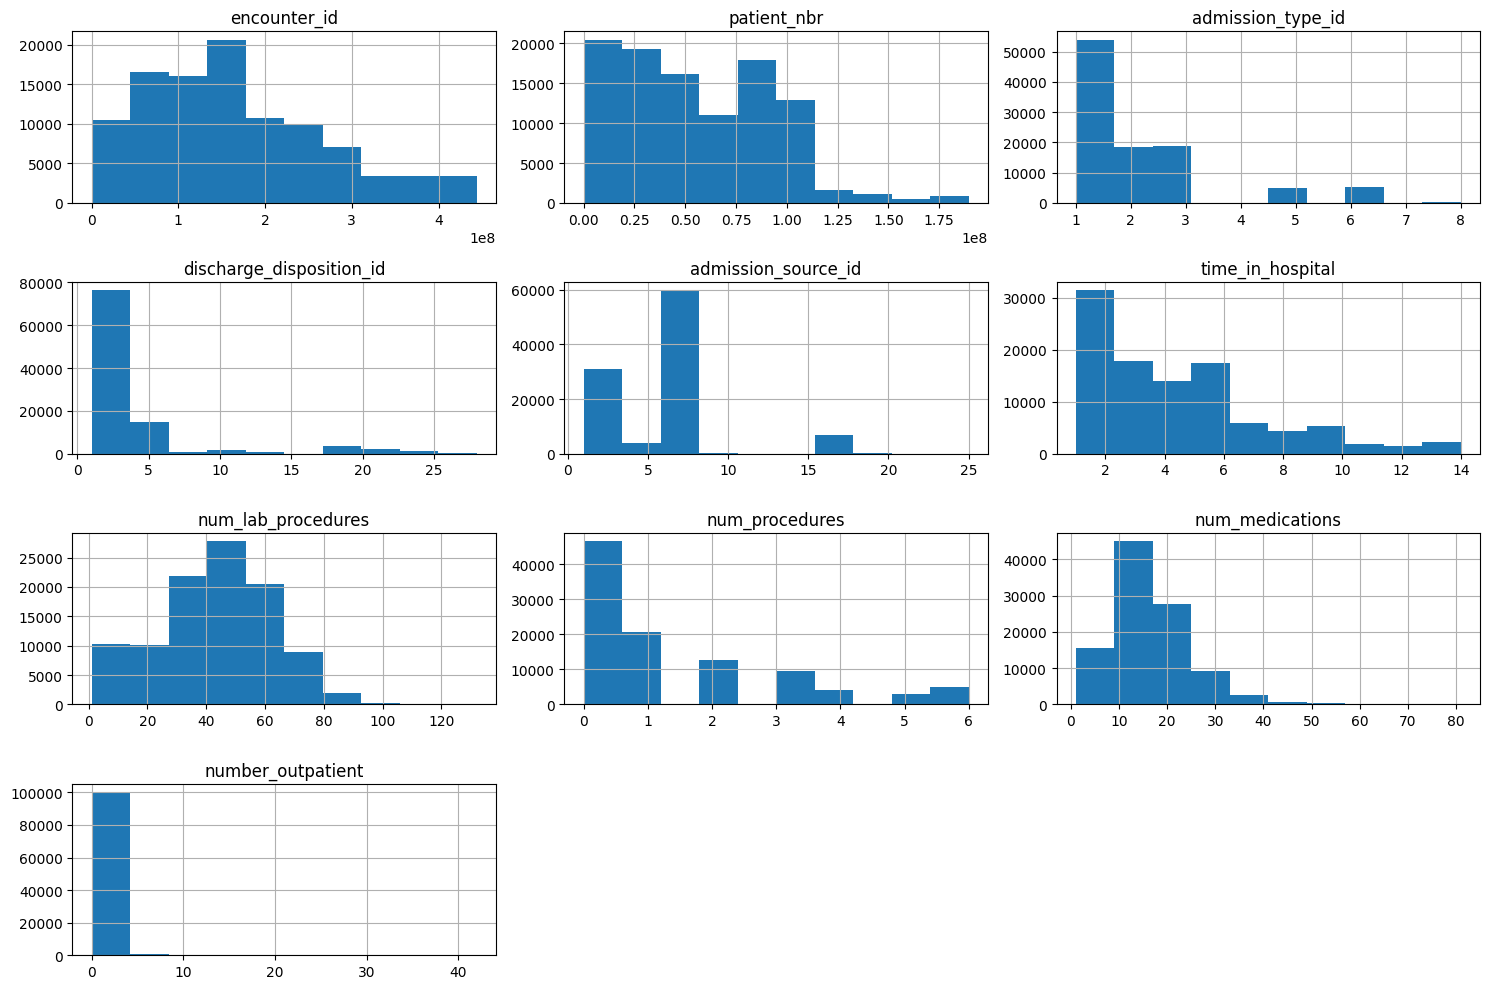

In [6]:
num_cols = df.select_dtypes(include=np.number).columns[:10]
df[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

## Correlation Heatmap

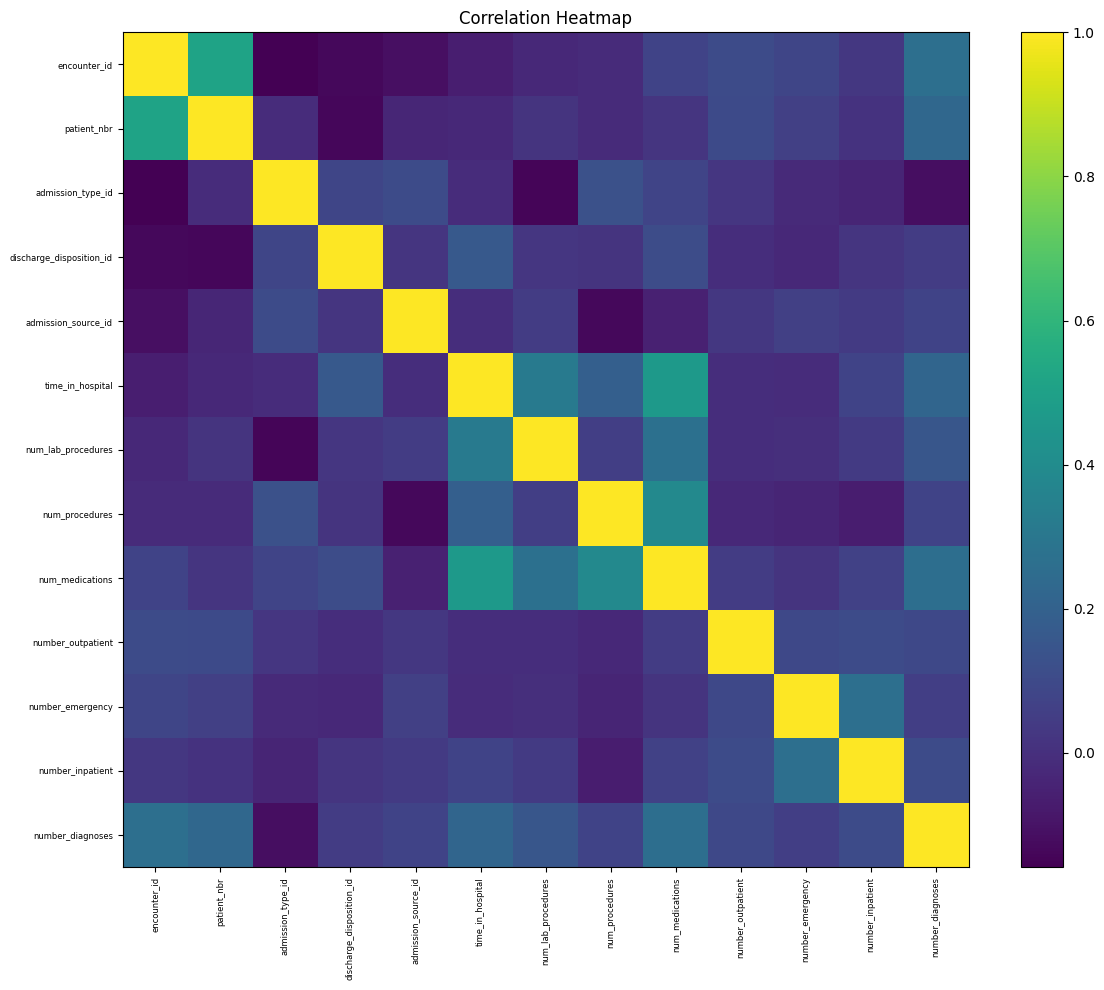

In [7]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,10))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=6)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Boxplots

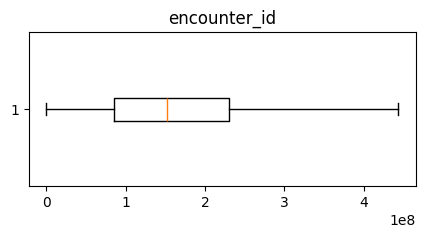

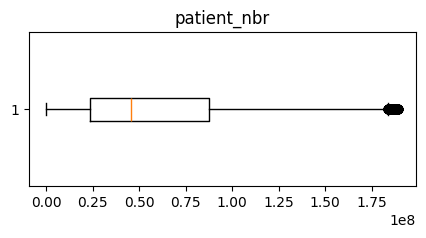

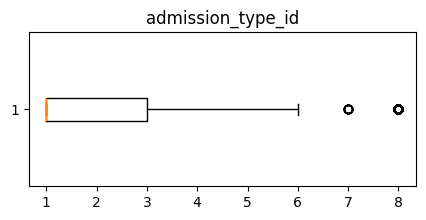

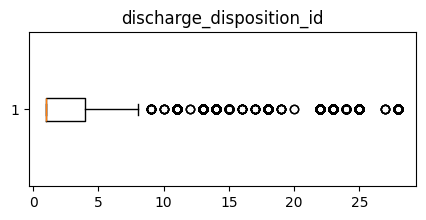

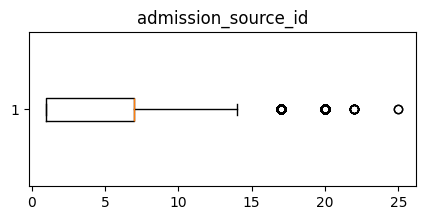

In [8]:
for col in list(num_cols)[:5]:
    plt.figure(figsize=(5,2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

## Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target = "readmitted_binary" if "readmitted_binary" in df.columns else "readmitted"
X = df.drop(columns=[target])
X = pd.get_dummies(X, drop_first=True)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
num = X_train.select_dtypes(include=np.number).columns
X_train[num] = scaler.fit_transform(X_train[num])
X_test[num] = scaler.transform(X_test[num])

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (81412, 2434)
Testing Shape: (20354, 2434)


## Conclusion

- Dataset loaded successfully.
- Missing values checked.
- Duplicate rows removed.
- Statistical summary generated.
- Target distribution visualized.
- Histograms, boxplots, and correlation heatmap created.
- Dataset prepared for machine learning.